In [2]:
!pip install "numpy==2.0.2" -q 2>/dev/null
!pip install faiss-cpu -q 2>/dev/null

In [3]:
import os
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['PYTHONHASHSEED'] = '123'

import random
random.seed(123)

import numpy as np
np.random.seed(123)

import torch
torch.manual_seed(123)
torch.cuda.manual_seed(123)

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import faiss
import seaborn as sns
import joblib

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, classification_report)

from torchvision import models, transforms

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


In [4]:
fdir = '/kaggle/input/datasets/abdulkatsir/datset/siputLaut'

filepaths = []
labels    = []
classlist = os.listdir(fdir)
for klass in classlist:
    classpath = os.path.join(fdir, klass)
    if os.path.isdir(classpath):
        for f in os.listdir(classpath):
            if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.webp')):
                filepaths.append(os.path.join(classpath, f))
                labels.append(klass)

df = pd.concat([pd.Series(filepaths, name='filepaths'),
                pd.Series(labels,    name='labels')], axis=1)

print(df['labels'].value_counts())
print(f'Total: {len(df)} gambar')

labels
Nerita undata          425
Planaxis sulcatus      425
Nerita melanotragus    425
Name: count, dtype: int64
Total: 1275 gambar


In [5]:
train_split = .70
test_split = .15
dummy_split = test_split / (1 - train_split)

train_df, dummy_df = train_test_split(
    df, 
    train_size=train_split, 
    shuffle      =True, 
    random_state =123,
    stratify     = df['labels'] 
)
valid_df, test_df = train_test_split(
    dummy_df, 
    train_size=dummy_split, 
    shuffle      =True, 
    random_state =123,
    stratify     = dummy_df['labels']
)

print('train_df:', len(train_df), ' valid_df:', len(valid_df), ' test_df:', len(test_df))

train_df: 892  valid_df: 191  test_df: 192


In [7]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

backbone_vgg = models.vgg16(pretrained=True).features
backbone_vgg = backbone_vgg.to(device)
backbone_vgg.eval()
print('VGG16 backbone siap!')

VGG16 backbone siap!


In [8]:
transform_vgg = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

def extract_vgg_features(img_path):
    img   = Image.open(img_path).convert('RGB')
    img_t = transform_vgg(img).unsqueeze(0).to(device)
    with torch.no_grad():
        feat = backbone_vgg(img_t)
        feat = feat.mean(dim=[2,3])
        feat = feat.cpu().numpy().flatten()
    return feat.astype(np.float32)

def extract_embedding(img_path):
    vgg_feat = extract_vgg_features(img_path)
    vgg_norm = vgg_feat / (np.linalg.norm(vgg_feat) + 1e-8)
    return vgg_norm 

#bangun memory bank
memory_bank = []
for img_path in train_df['filepaths']:
    memory_bank.append(extract_embedding(img_path))
memory_bank = np.vstack(memory_bank).astype(np.float32)

assert memory_bank.shape[1] == 512, "Dimensi fitur tidak sesuai ekspektasi VGG16"
print(f'Memory bank shape: {memory_bank.shape}')

#index FAISS
index = faiss.IndexFlatL2(memory_bank.shape[1])
index.add(memory_bank)
print(f'index siap')

Memory bank shape: (892, 512)
index siap


Mean: 0.155595 | Std: 0.041304


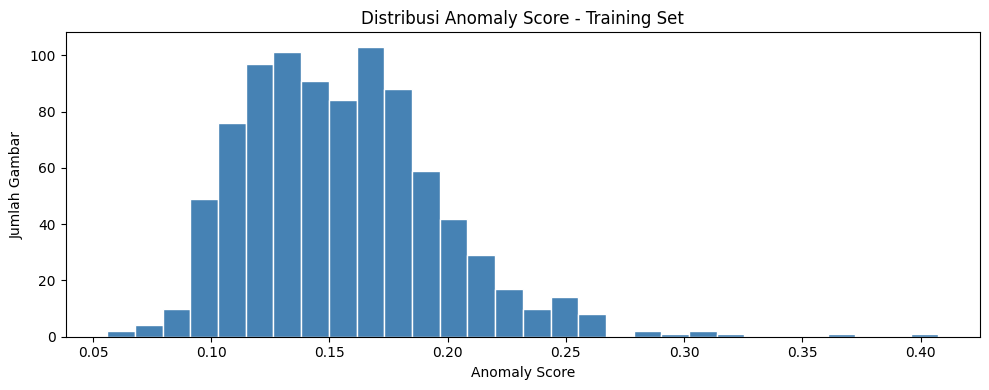

In [9]:
def anomaly_score(img_path, k=5):
    feat           = extract_embedding(img_path).reshape(1, -1)
    distances, _   = index.search(feat, k=k)
    score          = float(np.mean(distances))
    return score

train_scores = [anomaly_score(p) for p in train_df['filepaths']]
train_scores = np.array(train_scores)

mean       = np.mean(train_scores)
std        = np.std(train_scores)
print(f'Mean: {mean:.6f} | Std: {std:.6f}')

plt.figure(figsize=(10, 4))
plt.hist(train_scores, bins=30, color='steelblue', edgecolor='white')
plt.xlabel('Anomaly Score')
plt.ylabel('Jumlah Gambar')
plt.title('Distribusi Anomaly Score - Training Set')
plt.tight_layout()
plt.show()

In [10]:
valid_scores = [anomaly_score(p) for p in valid_df['filepaths']]
valid_labels = valid_df['labels'].tolist()

kelas = sorted(valid_df['labels'].unique().tolist())
print('Kelas terdeteksi:', kelas)


print(f'\n{"mult":6} {"thresh":10} {"Nerita mel":12} {"Nerita und":12} {"Planaxis":10} {"Avg":6}')
print('='*70)
for mult in [3.0, 3.5, 4.0, 4.5, 4.6, 4.7, 4.8, 4.9, 5.0, 5.1, 5.2, 5.3, 5.4, 5.5]:
    thresh      = mean + mult * std
    total_lolos = {k: 0 for k in kelas}
    total_count = {k: 0 for k in kelas}

    for i, score in enumerate(valid_scores):
        label = valid_labels[i]
        if label in total_count:
            total_count[label] += 1
            if score <= thresh:
                total_lolos[label] += 1

    persentase = {k: total_lolos[k] / max(total_count[k], 1) * 100 for k in kelas}
    avg = sum(persentase.values()) / len(kelas)

    row = f'{mult:<6} {thresh:>10.6f} '
    for k in kelas:
        row += f'{persentase[k]:>10.0f}% '
    row += f'{avg:>5.0f}%'
    print(row)

Kelas terdeteksi: ['Nerita melanotragus', 'Nerita undata', 'Planaxis sulcatus']

mult   thresh     Nerita mel   Nerita und   Planaxis   Avg   
3.0      0.279507         94%         98%         86%    93%
3.5      0.300159         95%        100%         92%    96%
4.0      0.320811         95%        100%         97%    97%
4.5      0.341463         97%        100%         97%    98%
4.6      0.345593         97%        100%         98%    98%
4.7      0.349724         97%        100%         98%    98%
4.8      0.353854         98%        100%         98%    99%
4.9      0.357984         98%        100%        100%    99%
5.0      0.362115         98%        100%        100%    99%
5.1      0.366245         98%        100%        100%    99%
5.2      0.370376        100%        100%        100%   100%
5.3      0.374506        100%        100%        100%   100%
5.4      0.378636        100%        100%        100%   100%
5.5      0.382767        100%        100%        100%   100%


In [11]:
THRESHOLD_FINAL = mean + 5.2 * std

# Hitung score test set
test_scores = [anomaly_score(p) for p in test_df['filepaths']]
test_labels = test_df['labels'].tolist()

# Evaluasi
total_lolos = {k: 0 for k in kelas}
total_count = {k: 0 for k in kelas}

for i, score in enumerate(test_scores):
    label = test_labels[i]
    if label in total_count:
        total_count[label] += 1
        if score <= THRESHOLD_FINAL:
            total_lolos[label] += 1

persentase = {k: total_lolos[k] / max(total_count[k], 1) * 100 for k in kelas}
avg = sum(persentase.values()) / len(kelas)

print(f'\nEVALUASI TEST SET:')
print('='*50)
for k in kelas:
    print(f'{k:<20}: {total_lolos[k]}/{total_count[k]} ({persentase[k]:.0f}%)')
print('='*50)
print(f'Rata-rata        : {avg:.0f}%')


EVALUASI TEST SET:
Nerita melanotragus : 64/64 (100%)
Nerita undata       : 64/64 (100%)
Planaxis sulcatus   : 64/64 (100%)
Rata-rata        : 100%


In [12]:
uji_dir   = '/kaggle/input/datasets/abdulkatsir/dataanomali/anomali'
uji_files = [f for f in os.listdir(uji_dir)
             if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.webp'))]

print(f'Total gambar uji: {len(uji_files)}')
print(f'Threshold       : {THRESHOLD_FINAL:.6f}')
print('=' * 60)

lolos, ditolak = [], []
anomali_scores = []
for fname in sorted(uji_files):
    img_path = os.path.join(uji_dir, fname)
    score    = anomaly_score(img_path)
    anomali_scores.append(score)
    status   = '✅ LOLOS' if score <= THRESHOLD_FINAL else '❌ DITOLAK'
    print(f'{fname:40s}: {score:.6f} -> {status}')
    (lolos if score <= THRESHOLD_FINAL else ditolak).append(fname)

print(f'\n{"=" * 60}')
print(f'Total LOLOS   : {len(lolos)}/{len(uji_files)} ({len(lolos)/len(uji_files)*100:.0f}%)')
print(f'Total DITOLAK : {len(ditolak)}/{len(uji_files)} ({len(ditolak)/len(uji_files)*100:.0f}%)')

Total gambar uji: 84
Threshold       : 0.370376
1130-1.png                              : 0.650662 -> ❌ DITOLAK
20260206_153733.png                     : 0.196935 -> ✅ LOLOS
20260206_161436.png                     : 0.265261 -> ✅ LOLOS
20260206_161452.png                     : 0.250338 -> ✅ LOLOS
20260220_155348.png                     : 0.460535 -> ❌ DITOLAK
20260220_155656.png                     : 0.433152 -> ❌ DITOLAK
20260220_160302.png                     : 0.236266 -> ✅ LOLOS
20260220_160402.png                     : 0.363595 -> ✅ LOLOS
20260220_165249.png                     : 0.494956 -> ❌ DITOLAK
20260220_165922.png                     : 0.401137 -> ❌ DITOLAK
20260220_170052.png                     : 0.457496 -> ❌ DITOLAK
20260220_170110.png                     : 0.404667 -> ❌ DITOLAK
20260220_170250.png                     : 0.548967 -> ❌ DITOLAK
20260220_170409.png                     : 0.415908 -> ❌ DITOLAK
20260220_170747.png                     : 0.512631 -> ❌ DITOLAK
20

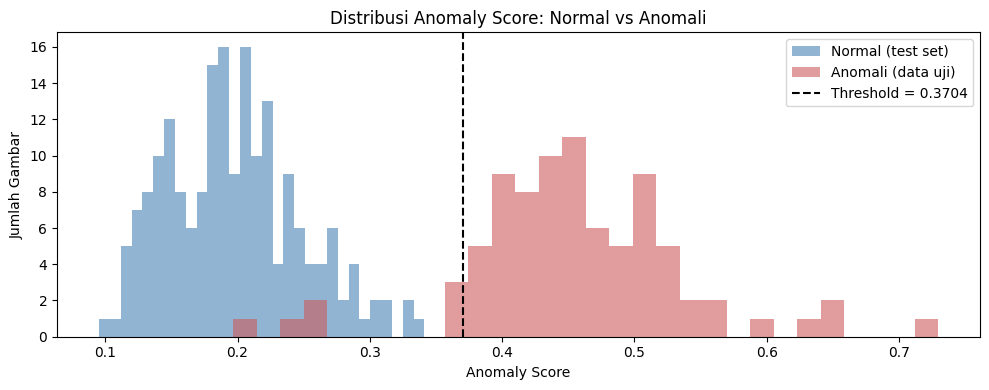

In [13]:
plt.figure(figsize=(10, 4))
plt.hist(test_scores, bins=30, alpha=0.6, label='Normal (test set)', color='steelblue')
plt.hist(anomali_scores, bins=30, alpha=0.6, label='Anomali (data uji)', color='indianred')
plt.axvline(THRESHOLD_FINAL, color='black', linestyle='--', label=f'Threshold = {THRESHOLD_FINAL:.4f}')
plt.xlabel('Anomaly Score')
plt.ylabel('Jumlah Gambar')
plt.title('Distribusi Anomaly Score: Normal vs Anomali')
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
save_dir = '/kaggle/working/dn2_model'
os.makedirs(save_dir, exist_ok=True)

# 1. Simpan bobot backbone VGG16
backbone_pt = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1).features
torch.save(backbone_pt.state_dict(), os.path.join(save_dir, 'vgg16_backbone.pth'))

# 2. Simpan FAISS index (IndexFlatL2 menyimpan seluruh vektor memory bank
faiss.write_index(index, os.path.join(save_dir, 'dn2_index.faiss'))

# 3. Simpan konfigurasi, threshold, dan ringkasan hasil pengujian
joblib.dump({
    'mean'        : float(mean),
    'std'         : float(std),
    'threshold'   : float(THRESHOLD_FINAL),
    'classes'     : kelas,
    'k'           : 5,
    'test_set_lolos_pct'   : round(avg, 2),
    'data_anomali_lolos'   : len(lolos),
    'data_anomali_ditolak' : len(ditolak),
    'data_anomali_total'   : len(uji_files),
}, os.path.join(save_dir, 'config.pkl'))

print('Semua komponen model tersimpan di:', save_dir)

Semua komponen model tersimpan di: /kaggle/working/dn2_model
